In [1]:
pip uninstall duckduckgo_search

^C
Note: you may need to restart the kernel to use updated packages.


In [1]:
from duckduckgo_search import ddg_images
from fastcore.all import *

def search_images_ddg(term, max_images=260):
    print(f"Searching for '{term}'")
    return L(ddg_images(term, max_results=max_images)).itemgot('image')

In [2]:
ims=search_images_ddg('gdd bear')
len(ims)

Searching for 'gdd bear'


0

In [14]:
from fastdownload import download_url
dest='images/grizzly.jpg'
download_url(ims[0],dest,show_progress=False)

IndexError: list index out of range

In [7]:
from fastai.vision.all import *

In [8]:
from fastai.vision.all import *
im=Image.open(dest)
im.to_thumb(128,128)

NameError: name 'dest' is not defined

In [17]:
bear_types='grizzly','black','teddy'
path=Path('bears')

In [14]:
if not path.exists():
    path.mkdir()
    for o in bear_types:
        dest=(path/o)
        dest.mkdir(exist_ok=True)
        results=search_images_ddg(f'{o} bear')
        download_images(dest,urls=results)

Searching for 'grizzly bear'
Searching for 'black bear'
Searching for 'teddy bear'


In [18]:
fns=get_image_files(path)

In [19]:
failed=verify_images(fns)
len(failed)


0

In [20]:
failed.map(Path.unlink)

(#0) []

In [21]:
len(failed)

0

## DATALOADERS


In [22]:
bears=DataBlock(
    blocks=(ImageBlock,CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2,seed=41),
    get_y=parent_label,
    item_tfms=Resize(128)
)

In [23]:
dls=bears.dataloaders(path)

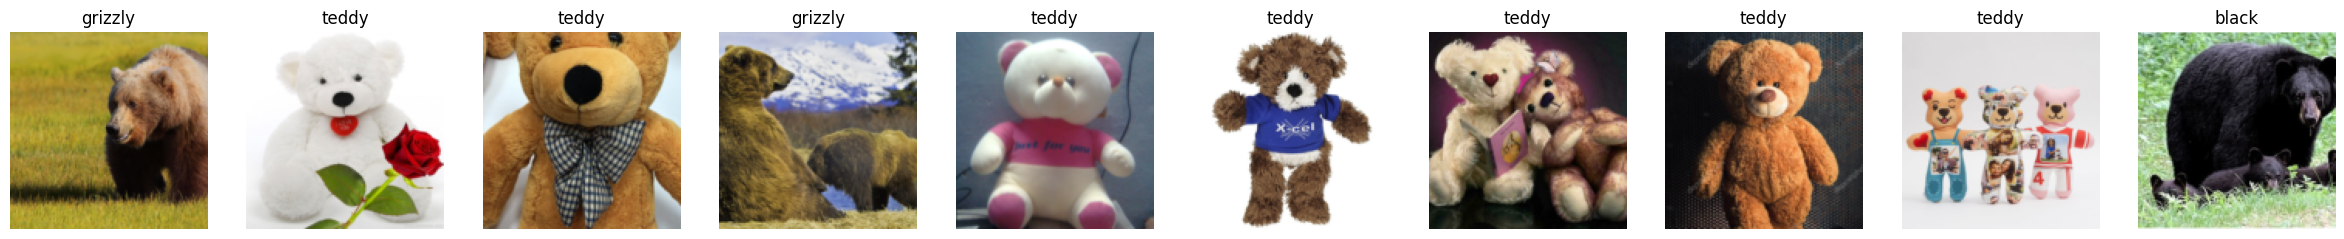

In [24]:
dls.valid.show_batch(max_n=10,nrows=1)

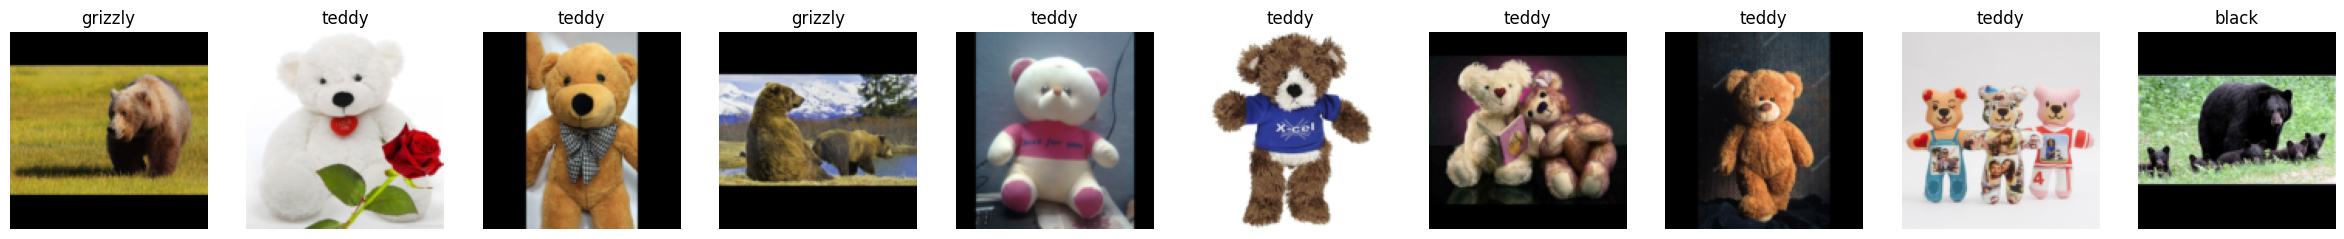

In [30]:
bears=bears.new(item_tfms=Resize(128,ResizeMethod.Pad,pad_mode='zeros'))
dls=bears.dataloaders(path)
dls.valid.show_batch(max_n=10,nrows=1)

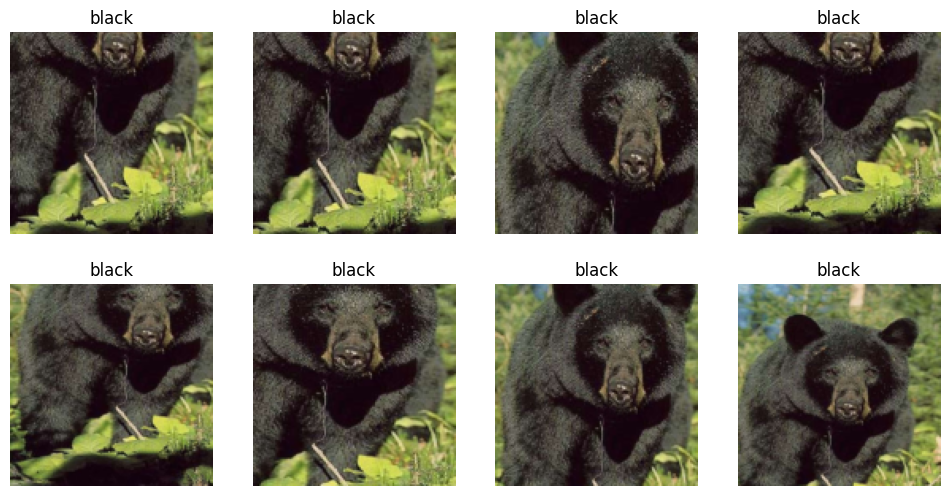

In [26]:
bears=bears.new(item_tfms=RandomResizedCrop(128,min_scale=0.3))
dls=bears.dataloaders(path)
dls.train.show_batch(max_n=8,nrows=2,unique=True)

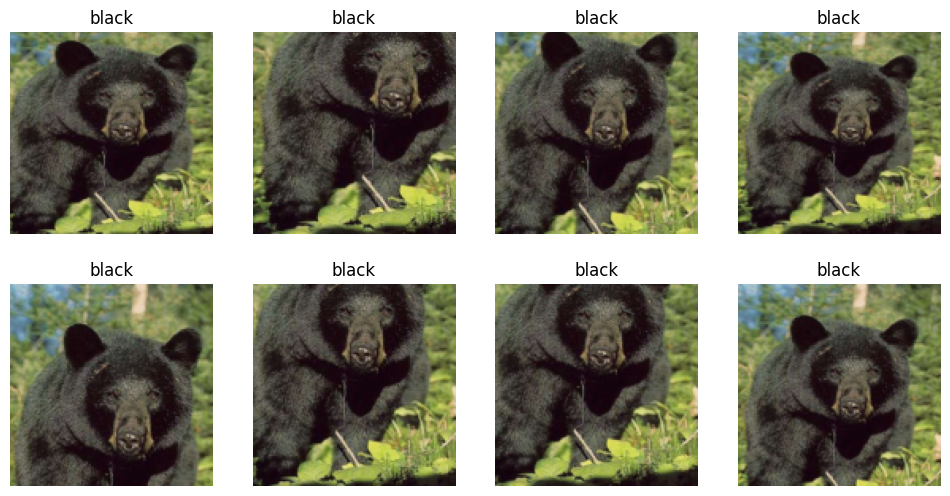

In [27]:
bears=bears.new(item_tfms=RandomResizedCrop(128,min_scale=0.5))
dls=bears.dataloaders(path)
dls.train.show_batch(max_n=8,nrows=2,unique=True)

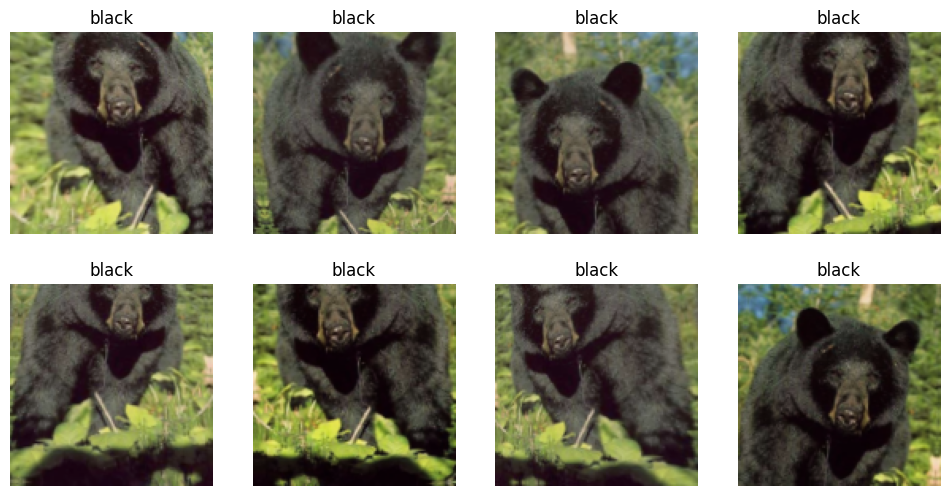

In [28]:
bears=bears.new(item_tfms=Resize(128),batch_tfms=aug_transforms())
dls=bears.dataloaders(path)
dls.train.show_batch(max_n=8,nrows=2,unique=True)

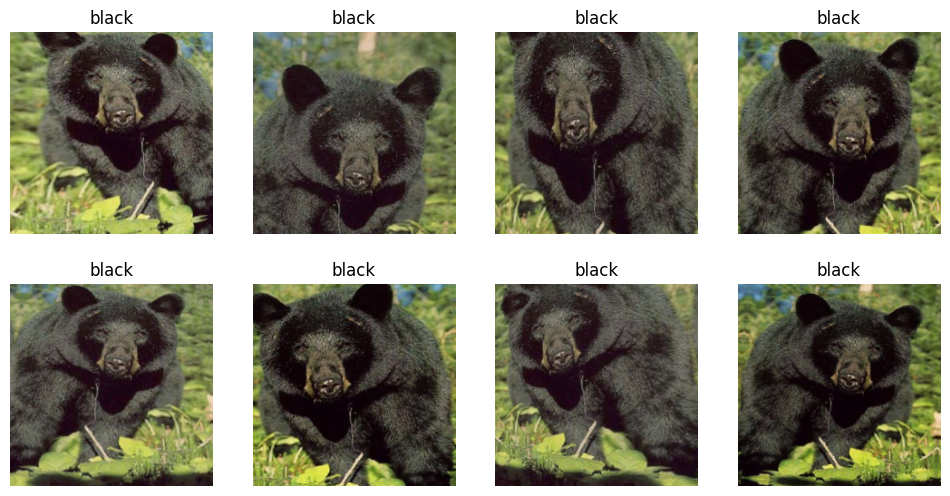

In [55]:
bears=bears.new(item_tfms=RandomResizedCrop(224,min_scale=0.5),batch_tfms=aug_transforms())
dls=bears.dataloaders(path,device=torch.device('cuda'))
dls.train.show_batch(max_n=8,nrows=2,unique=True)

In [56]:
learn=vision_learner(dls,resnet18,metrics=error_rate)


c:\Users\enesm\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\enesm\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [57]:
learn.fine_tune(4)